In [ ]:
import numpy as np

# Número de datos a generar
n_samples = 10000

# Generar datos sintéticos para horas de trabajo
# Suponemos que las horas de trabajo varían entre 0 y 16 horas, con una distribución normal alrededor de 8 horas
horas_trabajo = np.random.normal(loc=8, scale=3, size=n_samples)
horas_trabajo = np.clip(horas_trabajo, 0, 16).astype(int) # Limitar a un rango razonable y convertir a entero

# Generar datos sintéticos para el consumo de café basado en las horas de trabajo
# Suponemos que el consumo de café aumenta con las horas de trabajo, con algo de ruido y un mínimo
# Por ejemplo: consumo_cafe = 0.5 * horas_trabajo + 1 + ruido_aleatorio
consumo_cafe = (0.5 * horas_trabajo + 1 + np.random.normal(loc=0, scale=1.5, size=n_samples)).astype(int)
consumo_cafe = np.clip(consumo_cafe, 0, 10).astype(int) # Limitar el consumo a un rango realista (ej. 0 a 10 tazas)

# Convertir a listas
horas_trabajo_list = horas_trabajo.tolist()
consumo_cafe_list = consumo_cafe.tolist()

print(f"Longitud de horas_trabajo_list: {len(horas_trabajo_list)}")
print(f"Longitud de consumo_cafe_list: {len(consumo_cafe_list)}")
print("Primeros 10 datos de horas_trabajo:", horas_trabajo_list[:10])
print("Primeros 10 datos de consumo_cafe:", consumo_cafe_list[:10])

# Rangos para los coeficientes
rango_a_cafe = np.arange(-1, 2.1, 0.1)  # Rango para el término independiente (b)
rango_b_cafe = np.arange(-500, 501, 10) # Rango para el coeficiente de x (a)

print(rango_a_cafe)
print("#")
print(rango_b_cafe)

Longitud de horas_trabajo_list: 10000
Longitud de consumo_cafe_list: 10000
Primeros 10 datos de horas_trabajo: [7, 8, 2, 12, 3, 10, 10, 7, 4, 4]
Primeros 10 datos de consumo_cafe: [6, 4, 0, 9, 1, 8, 5, 3, 2, 3]
[-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01
  2.00000000e-01  3.00000000e-01  4.00000000e-01  5.00000000e-01
  6.00000000e-01  7.00000000e-01  8.00000000e-01  9.00000000e-01
  1.00000000e+00  1.10000000e+00  1.20000000e+00  1.30000000e+00
  1.40000000e+00  1.50000000e+00  1.60000000e+00  1.70000000e+00
  1.80000000e+00  1.90000000e+00  2.00000000e+00]
#
[-500 -490 -480 -470 -460 -450 -440 -430 -420 -410 -400 -390 -380 -370
 -360 -350 -340 -330 -320 -310 -300 -290 -280 -270 -260 -250 -240 -230
 -220 -210 -200 -190 -180 -170 -160 -150 -140 -130 -120 -110 -100  -90
  -80  -70  -60  -50  -40  -30  -20  -10    0   10   20   30   40   5

In [ ]:
mejor_error = float('inf')
mejor_a = None
mejor_b = None

# Bucle para probar diferentes combinaciones de coeficientes
for b in rango_b_cafe:
    for a in rango_a_cafe:
        error_acumulado = 0
        for indice, x in enumerate(horas_trabajo_list):

          # Calcular valores de y predichos por la ecuación
          y_pred = a * x + b

          # error_actual = y_pred - precios[indice]
          error_actual = (y_pred - consumo_cafe_list[indice])**2
          # print(x, precios[indice])

          error_acumulado = error_acumulado + error_actual

        # Actualizar los mejores coeficientes si encontramos un mejor ajuste
        error_acumulado = error_acumulado * (1 /(2 * len(horas_trabajo_list)))
        if error_acumulado < mejor_error:
            mejor_error = error_acumulado
            mejor_a = a
            mejor_b = b

print("Coeficiente de x (a) más cercano:", mejor_a)
print("Término independiente (b) más cercano:", mejor_b)


Coeficiente de x (m) más cercano: 0.5999999999999996
Término independiente (b) más cercano: 0


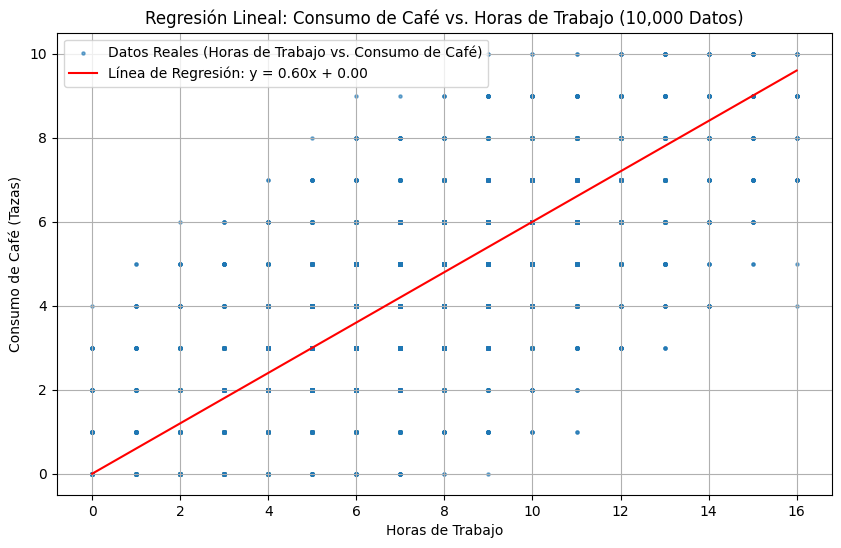

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear un array de horas de trabajo para la línea de regresión
x_line = np.array([min(horas_trabajo_list), max(horas_trabajo_list)])

# Calcular los valores y predichos por la línea de regresión
y_line = mejor_a * x_line + mejor_b

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.scatter(horas_trabajo_list, consumo_cafe_list, label='Datos Reales (Horas de Trabajo vs. Consumo de Café)', alpha=0.6, s=5) # 's' para el tamaño de los puntos
plt.plot(x_line, y_line, color='red', label=f'Línea de Regresión: y = {mejor_a:.2f}x + {mejor_b:.2f}')

plt.title('Regresión Lineal: Consumo de Café vs. Horas de Trabajo (10,000 Datos)')
plt.xlabel('Horas de Trabajo')
plt.ylabel('Consumo de Café (Tazas)')
plt.legend()
plt.grid(True)
plt.show()

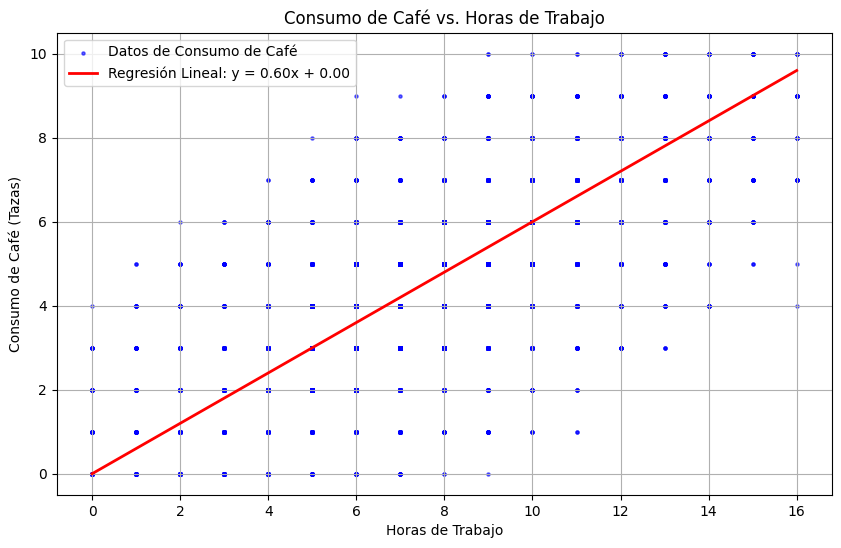

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plotData_cafe(x, y):
    # Grafica los puntos x e y en una figura nueva para el caso del café.

    fig = plt.figure(figsize=(10, 6))

    plt.scatter(x, y, color='blue', alpha=0.6, s=5, label='Datos de Consumo de Café')
    plt.ylabel('Consumo de Café (Tazas)')
    plt.xlabel('Horas de Trabajo')
    plt.title('Consumo de Café vs. Horas de Trabajo')
    plt.grid(True)

# Crear un array para la línea de regresión, usando los límites de horas_trabajo
x_line = np.array([min(horas_trabajo_list), max(horas_trabajo_list)])

# Calcular los valores y predichos por la línea de regresión
y_line = mejor_a * x_line + mejor_b

# Graficar los datos usando la función adaptada
plotData_cafe(horas_trabajo_list, consumo_cafe_list)

# Graficar la línea de ajuste (regresión lineal)
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Línea de Regresión: y = {mejor_a:.2f}x + {mejor_b:.2f}');
plt.legend(['Datos de Consumo de Café', f'Regresión Lineal: y = {mejor_a:.2f}x + {mejor_b:.2f}']);
plt.show()

He creado una función `plotData_cafe` que se encarga de graficar los puntos de tus datos, y luego he añadido la línea de regresión utilizando los coeficientes `mejor_a` y `mejor_b` que calculaste. Las etiquetas de los ejes y el título de la gráfica también se han actualizado para reflejar los datos de consumo de café y horas de trabajo.